In [1]:
import torch
print("PyTorch 版本:", torch.__version__)
print("CUDA 是否可用:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA 版本:", torch.version.cuda)
    print("cuDNN 版本:", torch.backends.cudnn.version())

PyTorch 版本: 2.5.0+cu124
CUDA 是否可用: True
CUDA 版本: 12.4
cuDNN 版本: 90100


In [12]:
import torch
print(torch)


<module 'torch' from '/root/miniconda3/lib/python3.12/site-packages/torch/__init__.py'>


In [13]:
! python --version

Python 3.12.3


In [14]:
import flash_attn
print("FlashAttention 版本:", flash_attn.__version__)
import flash_attn_2_cuda


FlashAttention 版本: 2.7.4.post1


In [15]:
import xformers
print("xFormers 版本:", xformers.__version__)

xFormers 版本: 0.0.28.post2


In [16]:
from src.utils.file_utils import find_latest_model_path

In [17]:
find_latest_model_path('Classifier')
find_latest_model_path('ClfAttnPl')

Found folder: checkpoints/classifier_20250527-164221


FileNotFoundError: No checkpoint found for model: ClfAttnPl

In [3]:
from torch.optim.lr_scheduler import (
    CosineAnnealingLR,
    CosineAnnealingWarmRestarts,
    CyclicLR,
    ExponentialLR,
    LambdaLR,
    MultiStepLR,
    ReduceLROnPlateau,
    StepLR,
    SequentialLR
)
# issubclass(StepLR, ReduceLROnPlateau)  # False
issubclass(SequentialLR, ReduceLROnPlateau)  # False


False

In [1]:
import src.catalogs.cd as cd
catalog = cd.CDStandard(
    root_dir="/root/autodl-tmp/chuandian_eq/data/CD2021/raw",
    catalog_file="/root/autodl-tmp/chuandian_eq/data/CD2021/raw/CD2021.dat"
)

Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/CD2021/raw.


/root/autodl-tmp/chuandian_eq/src/data/tpp_dataset.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(path)


In [2]:
catalog.full_sequence

Sequence(
  inter_times: [90735],
  arrival_times: [90734],
  t_start: 0.0,
  t_end: 19583.0,
  t_nll_start: 0.0,
  mag: [90734],
  latitude: [90734],
  longitude: [90734],
  depth: [90734]
)

<Axes: xlabel='Arrival time (days)', ylabel='Magnitude'>

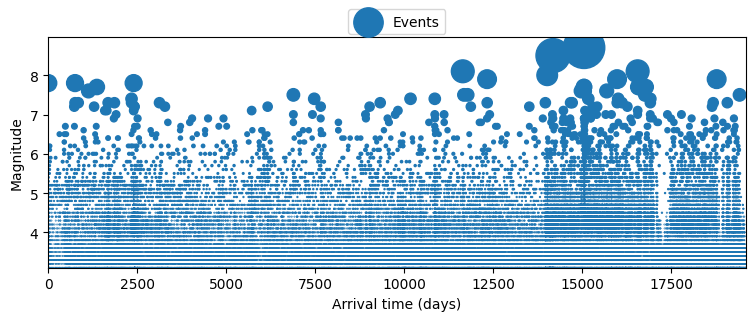

In [3]:
import src.catalogs.visualization as viz
viz.visualize_sequence(catalog.full_sequence)

In [26]:
import importlib    
importlib.reload(cd)

<module 'src.catalogs.cd' from '/root/autodl-tmp/chuandian_eq/src/catalogs/cd.py'>

In [27]:
cd_sliding = cd.CDSlidingWindow(
    root_dir="/root/autodl-tmp/chuandian_eq/data/CD2021/raw",  # 用于存放生成的数据的目录
    catalog_file="/root/autodl-tmp/chuandian_eq/data/CD2021/raw/CD2021.dat",  # 原始地震目录数据
    mag_completeness=3.0,              # 最小震级阈值
    window_size_days=180,              # 滑动窗口大小（单位：天）
    step_size_days=30,                 # 滑动步长（单位：天）
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15
)


Loading existing catalog from /root/autodl-tmp/chuandian_eq/data/CD2021/raw.
Generated 647 sliding window sequences.


In [17]:
import torch
mask = torch.tensor([True, True, True, False, False, False])
mask.nonzero().squeeze(-1)  # tensor([0, 1, 2])

tensor([0, 1, 2])